In [1]:
# imports

# tsa
import numpy as np
import pandas as pd
import datetime as dt

# data fetching
import yfinance as yf
import requests


# ds
from typing import Dict, Tuple, Union, Optional, List

# stats
import statsmodels.api as sm
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.stattools import coint, adfuller, kpss

from scipy.optimize import minimize_scalar

# visualisation
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

import seaborn as sns

### 1. data fetching and cleaning
dropnas, keep only  weekdays for tokenised (24 hr) markets to match (micro) gold futures 

In [2]:
start = "2020-01-01"
end = dt.datetime.now().strftime("%Y-%m-%d")

assets = ['PAXG-USD', 'XAUT-USD', 'MGC=F', 'GC=F']

In [3]:
 # download historical price data - yahoo finace
data = {}
for asset in assets:
    df = yf.download(asset, start=start, end=end)
    df.columns = [col[0] for col in df.columns] # comes as a tuple (field, asset)
    df.drop('Volume', axis=1, inplace=True)
    data[asset] = df

# align data on common dates - only weekdays cos of futures data
data_weekdays = {}
common_dates = set.intersection(*[set(df.index) for df in data.values()])
for asset in assets:
    data_weekdays[asset] = data[asset].loc[data[asset].index.isin(common_dates)].sort_index()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


### 2. exploratory data analysis

returns, log_returns, 
rolling_vol_20d, rolling_mean_20d, drawdown,
skew, kurtosis, z_score,
cumulative_returns

In [4]:
window = 20 # rounded down from 21 trading days in a month
colors = ['red', 'green', 'blue', 'springgreen', 'lightsteelblue', 'orange']
asset_colors = {asset: colors[i] for i, asset in enumerate(assets)}

eda = {asset: data_weekdays[asset].copy() for asset in assets}

for asset in assets:
    eda[asset]['Returns'] = eda[asset]['Close'].pct_change().dropna()
    eda[asset]['Cum_Returns'] = (1 + eda[asset]['Returns']).cumprod() - 1
    eda[asset]['Log_Returns'] = np.log(1 + eda[asset]['Returns'])
    eda[asset]['Sharpe_Ratio'] = eda[asset]['Returns'].rolling(window=window).mean() / eda[asset]['Returns'].rolling(window=window).std()
    eda[asset]['Ann_Vol'] = eda[asset]['Log_Returns'].rolling(window=window).std() * np.sqrt(252)
    eda[asset]['Rolling_Mean'] = eda[asset]['Returns'].rolling(window=window).mean()
    eda[asset]['Rolling_Mean_Log'] = eda[asset]['Log_Returns'].rolling(window=window).mean()
    eda[asset]['Drawdown'] = eda[asset]['Cum_Returns'] - eda[asset]['Cum_Returns'].cummax()
    eda[asset]['Skewness'] = eda[asset]['Returns'].rolling(window=window).skew()
    eda[asset]['Kurtosis'] = eda[asset]['Returns'].rolling(window=window).kurt()
    eda[asset]['Z_Scores'] = (eda[asset]['Returns'] - eda[asset]['Rolling_Mean']) / eda[asset]['Returns'].rolling(window=window).std()
    print(f"Asset: {asset}")
    print(eda[asset].tail(5))

Asset: PAXG-USD
                  Close         High          Low         Open   Returns  \
Date                                                                       
2026-08-31  4447.160645  4464.760254  4403.139160  4448.004883 -0.003481   
2026-09-01  4339.460449  4458.343750  4336.112793  4447.188477 -0.024218   
2026-09-02  4393.137207  4399.928223  4294.982422  4339.503906  0.012369   
2026-09-03  4479.804199  4508.794922  4391.202148  4393.153809  0.019728   
2026-09-04  4432.970215  4486.255859  4385.116699  4479.822754 -0.010454   

            Cum_Returns  Log_Returns  Sharpe_Ratio   Ann_Vol  Rolling_Mean  \
Date                                                                         
2026-08-31     1.823391    -0.003487      0.268369  0.285165      0.004873   
2026-09-01     1.755014    -0.024516      0.179134  0.303475      0.003455   
2026-09-02     1.789092     0.012294      0.098890  0.255684      0.001597   
2026-09-03     1.844115     0.019536      0.171277  0.262170 

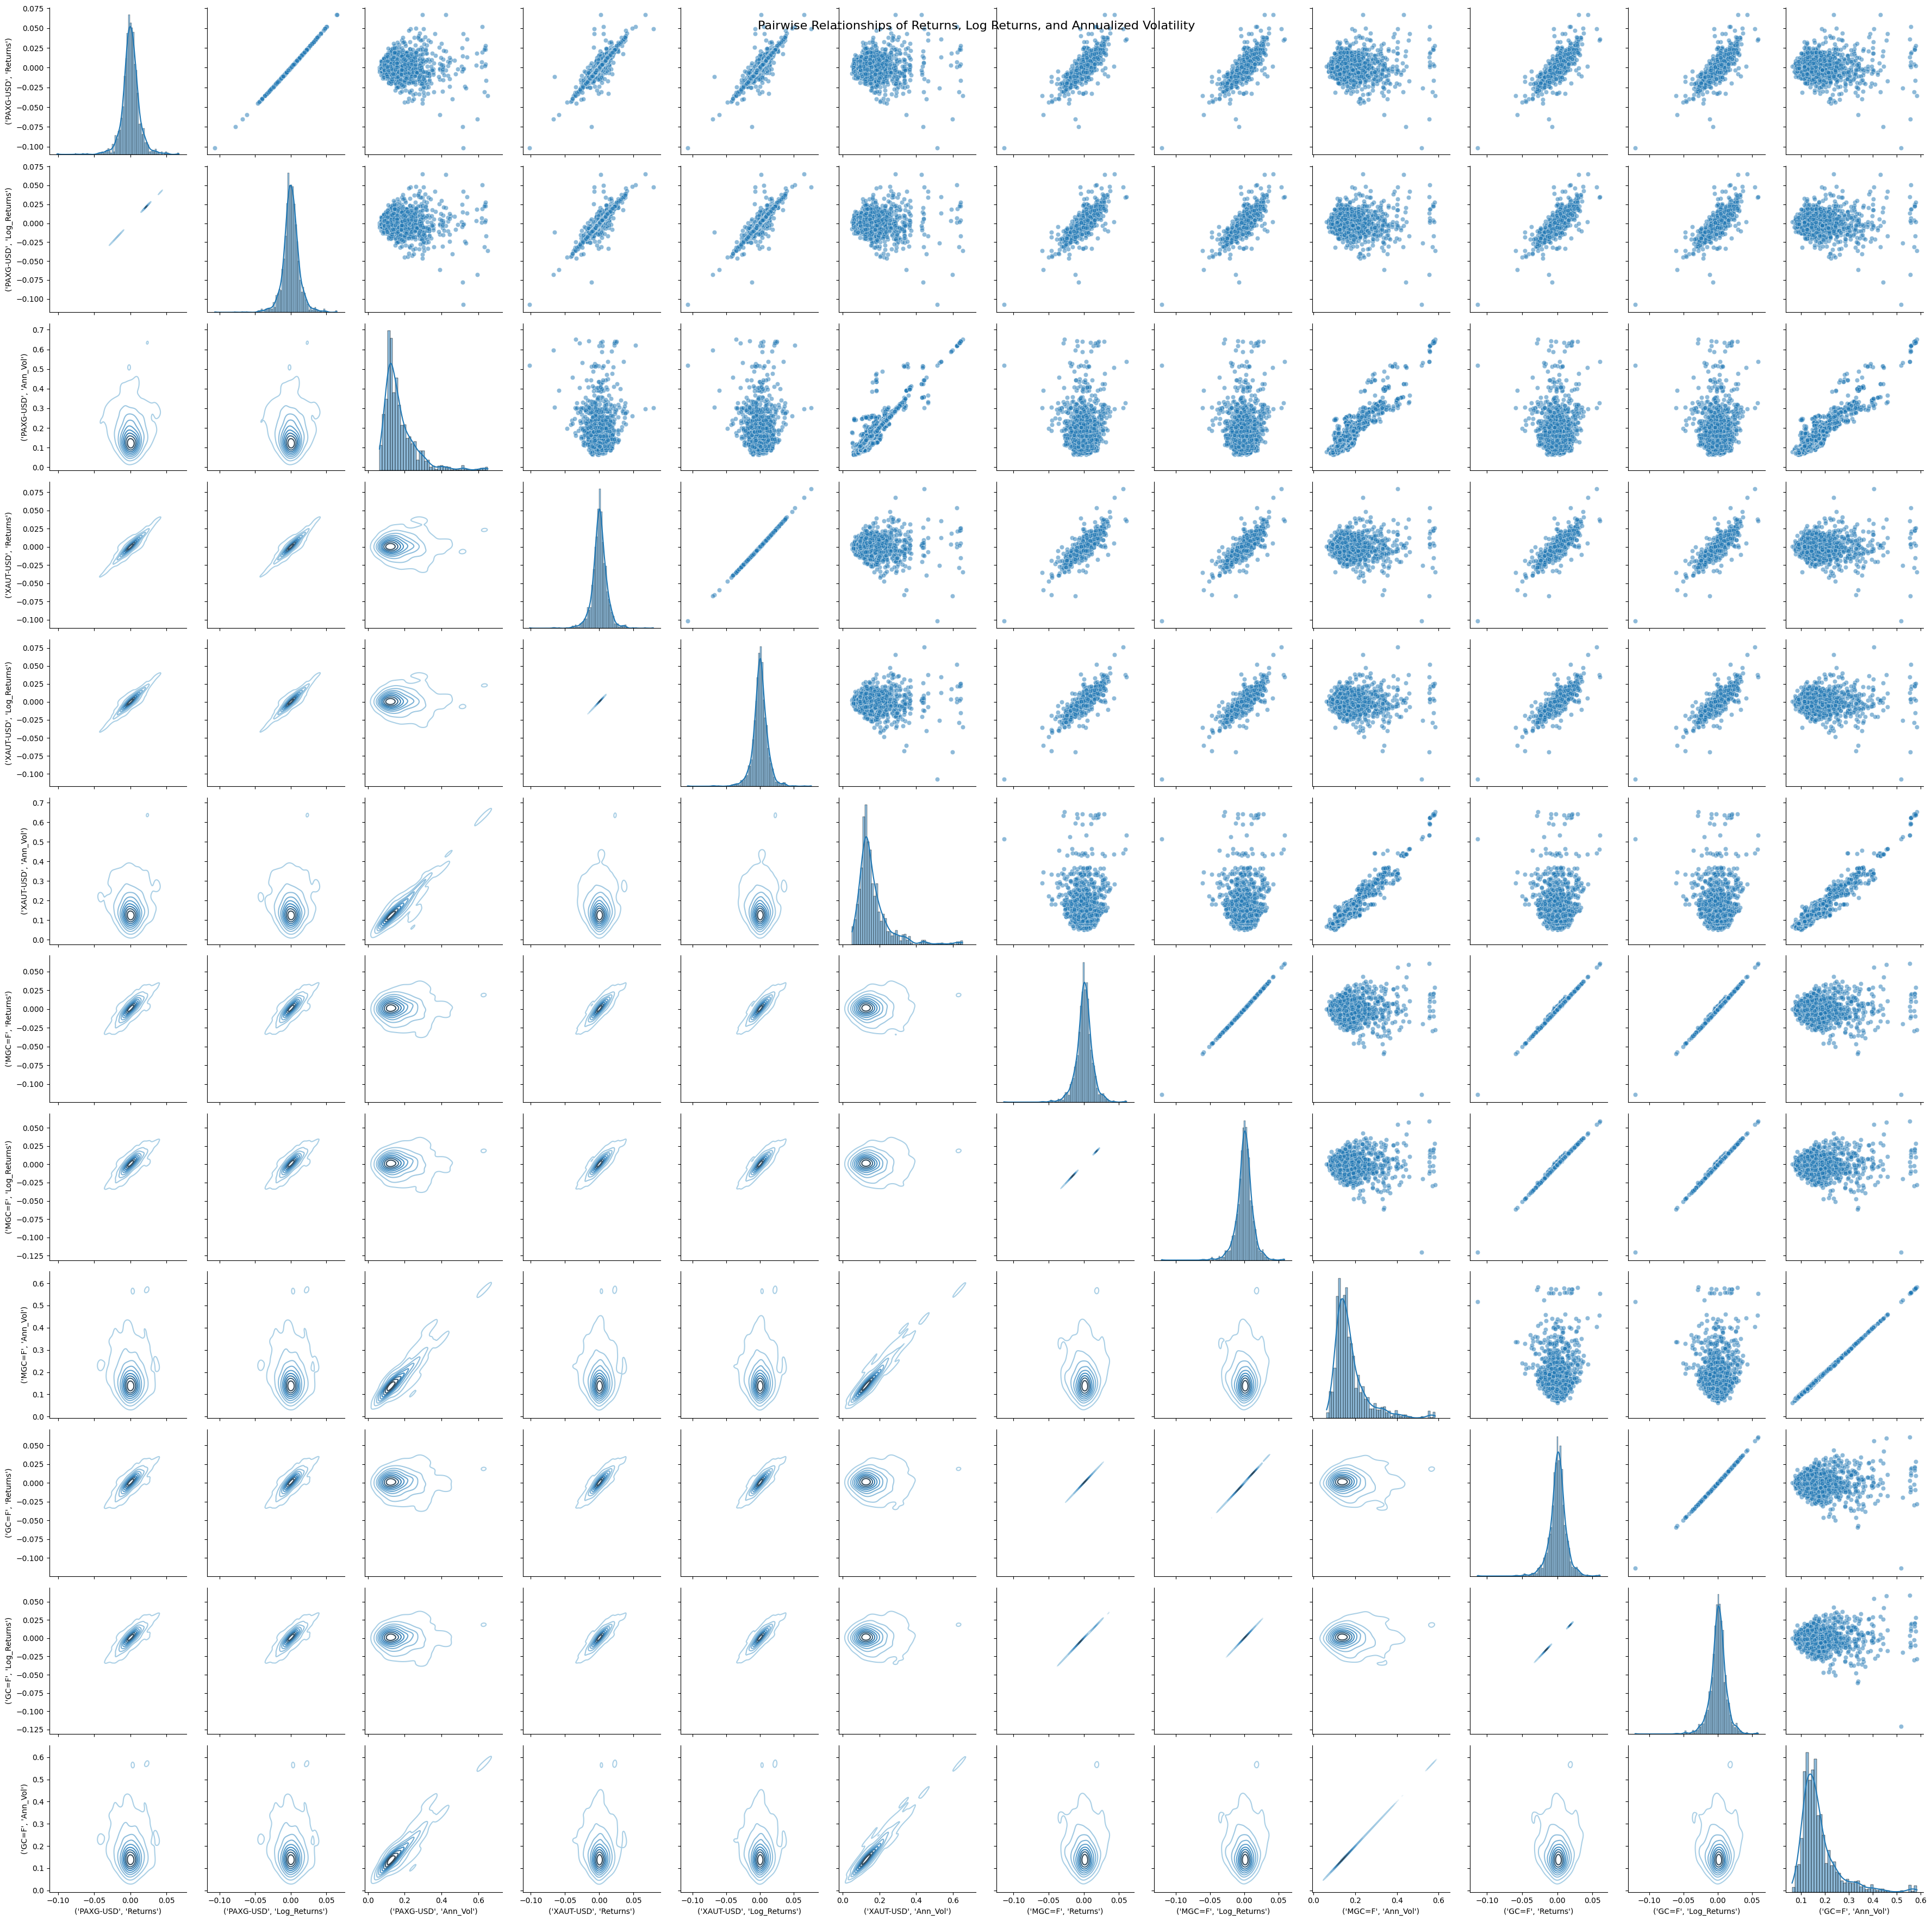

In [5]:
df_plotting = pd.concat(
    [eda[asset][['Returns', 'Log_Returns', 'Ann_Vol']] for asset in assets],
    axis=1,
    keys=assets
)

g = sns.PairGrid(df_plotting, diag_sharey=False, height=3)
g.map_upper(sns.scatterplot, alpha=0.5)
g.map_lower(sns.kdeplot, cmap="Blues_d")
g.map_diag(sns.histplot, kde=True, stat="density", alpha=0.5)



g.figure.suptitle("Pairwise Relationships of Returns, Log Returns, and Annualized Volatility", fontsize=16)
plt.xlabel("Returns, Log Returns, and Annualized Volatility")
plt.ylabel("Returns, Log Returns, and Annualized Volatility")

plt.show()


### 3. correlation and cointegration analysis

In [6]:
# correlation and cointegration matrices 
corr_matrix = np.zeros((len(assets), len(assets)))
coint_matrix = np.zeros((len(assets), len(assets)))

for i in range(len(assets)):
    for j in range(i):
        prices = pd.concat(
            [
                data_weekdays[assets[i]]["Close"],
                data_weekdays[assets[j]]["Close"],
            ],
            axis=1,
            join="inner",
        ).dropna()

        asset_i = prices.iloc[:, 0]
        asset_j = prices.iloc[:, 1]

        corr = asset_i.corr(asset_j)
        _, pvalue, _ = coint(
            asset_i,
            asset_j,
            trend="c",
            method="aeg",
            autolag="aic",
        )

        corr_matrix[i, j] = corr_matrix[j, i] = corr
        coint_matrix[i, j] = coint_matrix[j, i] = pvalue

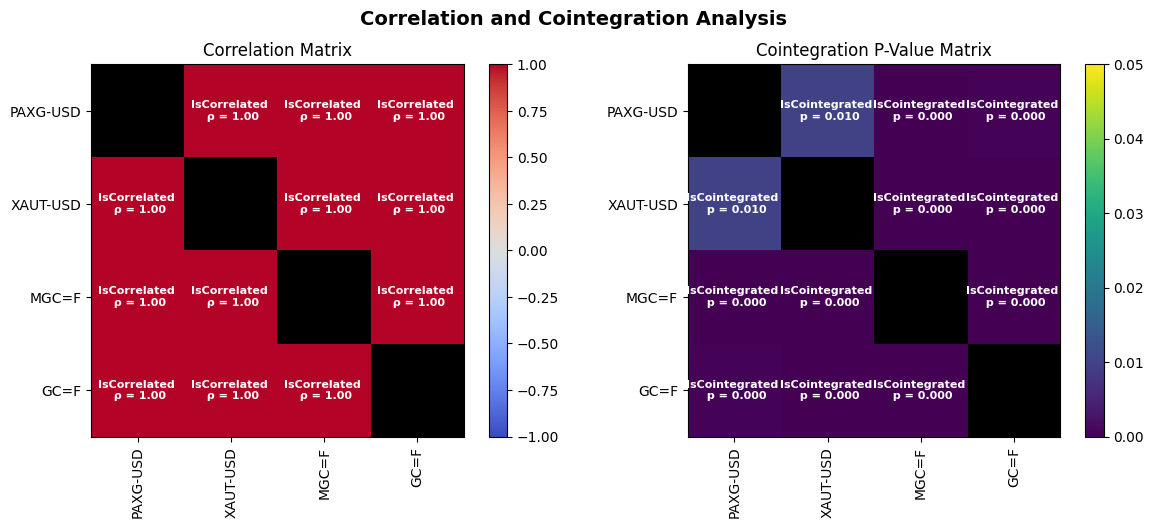

In [7]:
# corr coint plots
plt.subplots(1, 2, figsize=(12, 5))

# correlation Matrix with black zeros
plt.subplot(1, 2, 1)
plt.title('Correlation Matrix')
# create custom colormap where 0 values are black

corr_cmap = plt.cm.coolwarm.copy()
corr_cmap.set_bad('black')  # set NaN/masked values to black

# mask zero values to make them black
corr_masked = np.ma.masked_where(np.abs(corr_matrix) < 1e-10, corr_matrix)
im1 = plt.imshow(corr_masked, cmap=corr_cmap, vmin=-1, vmax=1)
plt.xticks(range(len(assets)), assets, rotation=90)
plt.yticks(range(len(assets)), assets)
for i in range(len(assets)):
    for j in range(len(assets)):
        if i != j and abs(corr_matrix[i, j]) >= 0.7: # check for strong correlation
            plt.text(j, i, f"IsCorrelated \n ρ = {corr_matrix[i, j]:.2f}", ha='center', va='center', 
                    color='white', fontsize=8, weight='bold')

plt.colorbar(im1)  

# cointegration Matrix with text annotations
coint_cmap = plt.cm.viridis.copy()
coint_cmap.set_bad('black')  # Set values below vmin to white
coint_masked = np.ma.masked_where(coint_matrix == 0, coint_matrix)  # Mask non-significant values
plt.subplot(1, 2, 2)
plt.title('Cointegration P-Value Matrix')
im2 = plt.imshow(coint_masked, cmap=coint_cmap, vmin=0, vmax=0.05)
plt.xticks(range(len(assets)), assets, rotation=90)
plt.yticks(range(len(assets)), assets)
# Add text annotations for significant cointegration
for i in range(len(assets)):
    for j in range(len(assets)):
        if i != j and coint_matrix[i, j] < 0.05:  # Skip diagonal and check significance
            plt.text(j, i, f'IsCointegrated \n p = {coint_matrix[i, j]:.3f}', ha='center', va='center', 
                    color='white', fontsize=8, weight='bold')
        
plt.colorbar(im2)

plt.suptitle('Correlation and Cointegration Analysis', fontsize=14, fontweight='bold', y=1)
plt.savefig("corr-coint-matrices_white.png", dpi=300, bbox_inches="tight", transparent=False)
plt.tight_layout()
fig = plt.gcf()

for ax in fig.axes:
    ax.tick_params(axis='both', colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_color('white')
for txt in fig.texts:
    txt.set_color('white')

fig.savefig("corr-coint-matrices_black.png", dpi=300, bbox_inches="tight", transparent=True)

# use black styling for in notebook display
for ax in fig.axes:
    ax.tick_params(axis='both', colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.title.set_color('black')
    for spine in ax.spines.values():
        spine.set_color('black')

for txt in fig.texts:
    txt.set_color('black')


plt.rcdefaults()
plt.show()




correlation plots show  high correlations (ρ = 1, expected) for all pairwise selections
cointegration plots show engle granger p values < 0.05, can reject H0 of no cointegration, residuals are I(0) stationary; no unit root

### 4. initial parameter settings
windows for rolling calculations (mean, std, and so on)
validation splitting parameters
significance testing thresholds

In [8]:
# params

# trading windows
window = 20  # rounded down from 21 trading days in a month
beta_window = window # same as window for no
windows = [5, 10, 20, 30, 60, 90, 120, 180, 252] # trading days in a year; 1w, 2w, 1m, 1q, 2q, 3q, 6m, 1y

# train test splitting, validation windows
train_start = min(df.index.min() for df in data_weekdays.values()).strftime('%Y-%m-%d') # first date in the data
train_end = '2023-12-31' # 4 years from 2020-01-01 to 2023-12-31
test_start = '2024-01-01' # 1 year from 2024-01-01 to 2024-12-31 or train_end + 1 day
test_end = max(df.index.max() for df in data_weekdays.values()).strftime('%Y-%m-%d') # last date in the data

# significance testing thresholds
thresholds = {'90%': 0.10, '95%': 0.05, '99%': 0.01, '99.9%': 0.001}
threshold_colors = {'90%': 'blue', '95%': 'orange', '99%': 'red', '99.9%': 'purple'}

### 5. spread and beta computation

In [9]:
def compute_spread(data, asset1, asset2, beta=True, rolling_window=window,
                   min_periods=None, debug=True):
    if min_periods is None:
        min_periods = rolling_window # default to rolling_window if not provided
    
    # ONE shared, de-duplicated, sorted index -> no positional/label drift
    j = (data[asset1][['Close']].rename(columns={'Close': 'y'})
         .join(data[asset2][['Close']].rename(columns={'Close': 'x'}), how='inner'))
    j = j[~j.index.duplicated(keep='first')].sort_index()
    y, x = j['y'], j['x']

    if not beta:
        spread = (y - x).rename('spread')
        return spread, pd.Series(1.0, index=spread.index, name='beta')

    # rolling OLS slope (with intercept) == cov(y,x)/var(x) — vectorised, exact
    beta_series = (y.rolling(rolling_window, min_periods=min_periods).cov(x)
                   / x.rolling(rolling_window, min_periods=min_periods).var()).rename('beta')
    spread = (y - beta_series * x)
    spread.name = f'{asset1}_{asset2}_spread_rolling_beta_{rolling_window}d'

    if debug:
        v = beta_series.dropna()
        print(f"Rolling Beta {asset1}-{asset2} (w={rolling_window}): mean {v.mean():.4f} "
              f"std {v.std():.4f} min {v.min():.4f} max {v.max():.4f} "
              f"valid {len(v)}/{len(beta_series)}")
    return spread, beta_series

In [10]:
# compute spreads w/ and w/o beta adjustments

spreads = {
    'PAXG-XAUT': compute_spread(data,'PAXG-USD', 'XAUT-USD', beta=False)[0],
    'PAXG-XAU': compute_spread(data_weekdays,'PAXG-USD', 'GC=F', beta=False)[0],
    'XAUT-XAU': compute_spread(data_weekdays,'XAUT-USD', 'GC=F', beta=False)[0],
    'PAXG-MGC': compute_spread(data_weekdays,'PAXG-USD', 'MGC=F', beta=False)[0],
    'XAUT-MGC': compute_spread(data_weekdays,'XAUT-USD', 'MGC=F', beta=False)[0],
    'XAU-MGC': compute_spread(data_weekdays,'GC=F', 'MGC=F', beta=False)[0],
}

spreads_beta = {
    'PAXG-XAUT': compute_spread(data,'PAXG-USD', 'XAUT-USD',rolling_window=beta_window, beta=True)[0],
    'PAXG-XAU': compute_spread(data_weekdays,'PAXG-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-XAU': compute_spread(data_weekdays,'XAUT-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'PAXG-MGC': compute_spread(data_weekdays,'PAXG-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-MGC': compute_spread(data_weekdays,'XAUT-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAU-MGC': compute_spread(data_weekdays,'GC=F', 'MGC=F', rolling_window=beta_window, beta=True)[0],
}

Rolling Beta PAXG-USD-XAUT-USD (w=20): mean 0.9526 std 0.1915 min -0.0904 max 1.8371 valid 2386/2405
Rolling Beta PAXG-USD-GC=F (w=20): mean 0.9271 std 0.1693 min 0.1475 max 1.5984 valid 1636/1655
Rolling Beta XAUT-USD-GC=F (w=20): mean 0.9232 std 0.1207 min 0.2574 max 1.3061 valid 1636/1655
Rolling Beta PAXG-USD-MGC=F (w=20): mean 0.9244 std 0.1786 min 0.1094 max 1.5721 valid 1636/1655
Rolling Beta XAUT-USD-MGC=F (w=20): mean 0.9217 std 0.1243 min 0.3341 max 1.3061 valid 1636/1655
Rolling Beta GC=F-MGC=F (w=20): mean 0.9976 std 0.0341 min 0.8444 max 1.1081 valid 1636/1655


In [11]:
# check for and drop NaNs from each spread series

print(f"NaN counts before dropping from naive spread series: {[series.isna().sum() for series in spreads.values()]}")
spreads = {name: series.dropna() for name, series in spreads.items()}

print(f"NaN counts before dropping: {[series.isna().sum() for series in spreads_beta.values()]}")
spreads_beta = {name: series.dropna() for name, series in spreads_beta.items()}

NaN counts before dropping from naive spread series: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
NaN counts before dropping: [np.int64(19), np.int64(19), np.int64(19), np.int64(19), np.int64(19), np.int64(19)]


normalize spreads

In [12]:
# spread normalisation - zscores
# z-scores
rolling_zscore = {
    name: (series - series.rolling(window=window).mean()) / series.rolling(window=window).std()
    for name, series in spreads.items()
}

exp_zscore = {
    name: (series - series.ewm(span=window, adjust=False).mean()) / series.ewm(span=window, adjust=False).std()
    for name, series in spreads.items()
}

rolling_zscore_beta = {
    name: (series - series.rolling(window=window).mean()) / series.rolling(window=window).std()
    for name, series in spreads_beta.items()
}

exp_zscore_beta = {
    name: (series - series.ewm(span=window, adjust=False).mean()) / series.ewm(span=window, adjust=False).std()
    for name, series in spreads_beta.items()
}

# add z-score columns directly into the existing spreads dict
for name, series in spreads.items():
    spreads[name] = series.to_frame(name='spread')
    spreads[name]['rolling_zscore'] = rolling_zscore[name]
    spreads[name]['exp_zscore'] = exp_zscore[name]

for name, series in spreads_beta.items():
    spreads_beta[name] = series.to_frame(name='spread')
    spreads_beta[name]['rolling_zscore'] = rolling_zscore_beta[name]
    spreads_beta[name]['exp_zscore'] = exp_zscore_beta[name]
  

In [13]:
# split by pairs
paxg_xaut_spread = spreads['PAXG-XAUT']
paxg_xau_spread = spreads['PAXG-XAU']
xaut_xau_spread = spreads['XAUT-XAU']
paxg_xaut_spread_beta = spreads_beta['PAXG-XAUT']
paxg_xau_spread_beta = spreads_beta['PAXG-XAU']
xaut_xau_spread_beta = spreads_beta['XAUT-XAU']

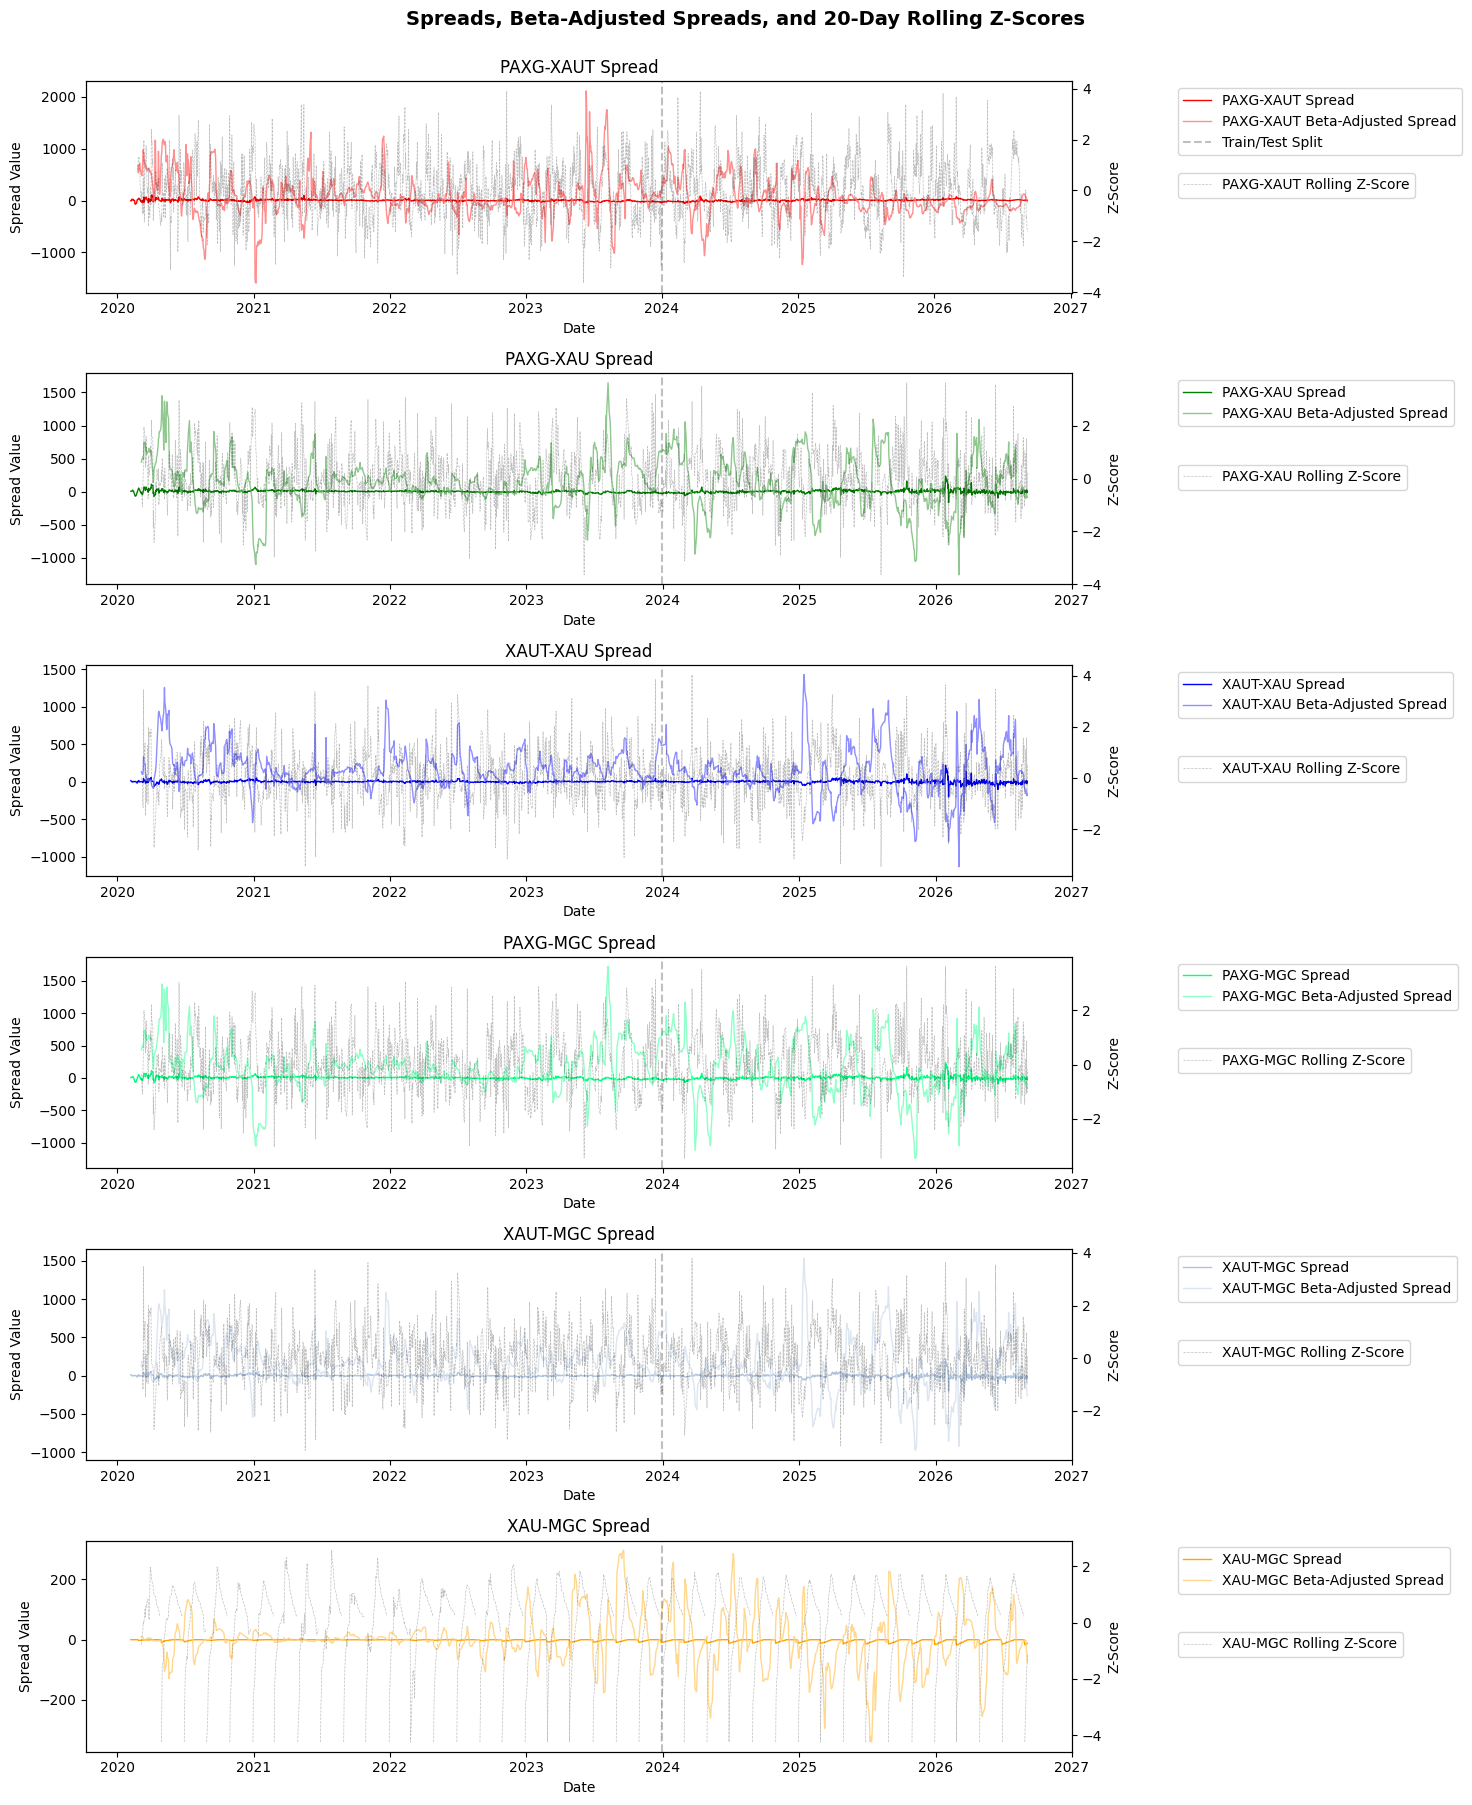

In [14]:
# plot of spreads, rolling z-scores, and beta-adjusted spreads
names = ['PAXG-XAUT', 'PAXG-XAU', 'XAUT-XAU', 'PAXG-MGC', 'XAUT-MGC', 'XAU-MGC']
fig, axs = plt.subplots(len(names), 1, figsize=(15, 3*len(names)))#, sharex=True)

colors = ['red', 'green', 'blue', 'springgreen', 'lightsteelblue', 'orange']



for i, name in enumerate(names):
    # Original Spread
    axs[i].plot(spreads[name]['spread'], label=f'{name} Spread', color = colors[i], alpha=1, linewidth=1)
    axs[i].set_title(f'{name} Spread')
    axs[i].legend(loc='upper left', bbox_to_anchor=(1.1, 1))
    axs[i].set_xlabel('Date')
    axs[i].set_ylabel('Spread Value')
    
    # Beta-adjusted spread with lighter shade of the same base color
    base = np.array(mcolors.to_rgb(colors[i]))
    lighter_color = tuple(base + (1 - base) * 0.45)  # increase toward white
    axs[i].plot(
        spreads_beta[name]['spread'],
        color=lighter_color,
        label=f'{name} Beta-Adjusted Spread',
        alpha=0.8,
        linewidth=1
    )
    axs[i].legend(loc='upper left', bbox_to_anchor=(1.1, 1))

    # Z-Scores
    twin = axs[i].twinx()
    twin.plot(spreads[name]['rolling_zscore'], label=f'{name} Rolling Z-Score', color='black', alpha=0.25, linestyle='--', linewidth=0.5)
    twin.legend(loc='upper left', bbox_to_anchor=(1.1, 0.6))
    twin.set_ylabel('Z-Score')

    axs[i].axvline(
        pd.Timestamp(train_end),
        color='black',
        linestyle='--',
        alpha=0.25,
        label='Train/Test Split' if i == 0 else '_nolegend_'
    )

    if i == 0:
        axs[i].legend(loc='upper left', bbox_to_anchor=(1.1, 1))
plt.suptitle(f'Spreads, Beta-Adjusted Spreads, and {window}-Day Rolling Z-Scores', fontsize=14, fontweight='bold', y= 1)
plt.tight_layout()

# # save fig
# plt.savefig('spread_bspread_zscore_plot_white.png', dpi=300, bbox_inches='tight', transparent=False)

plt.show()



### 6. train/test splitting

In [15]:
# train/test split by date

# truncate each asset's dataframe (no overlap: test is strictly after train_end)
data_train = {a: d.loc[d.index <= train_end] for a, d in data_weekdays.items()}
data_test  = {a: d.loc[d.index >  train_end] for a, d in data_weekdays.items()}

full_spreads = {
    'PAXG-XAUT': compute_spread(data_weekdays, 'PAXG-USD', 'XAUT-USD',rolling_window=beta_window, beta=False)[0],
    'PAXG-XAU': compute_spread(data_weekdays,'PAXG-USD', 'GC=F', rolling_window=beta_window, beta=False)[0],
    'XAUT-XAU': compute_spread(data_weekdays,'XAUT-USD', 'GC=F', rolling_window=beta_window, beta=False)[0],
    'PAXG-MGC': compute_spread(data_weekdays,'PAXG-USD', 'MGC=F', rolling_window=beta_window, beta=False)[0],
    'XAUT-MGC': compute_spread(data_weekdays,'XAUT-USD', 'MGC=F', rolling_window=beta_window, beta=False)[0],
    'XAU-MGC': compute_spread(data_weekdays,'GC=F', 'MGC=F', rolling_window=beta_window, beta=False)[0],
}

full_spreads_beta = {
    'PAXG-XAUT': compute_spread(data_weekdays,'PAXG-USD', 'XAUT-USD',rolling_window=beta_window, beta=True)[0],
    'PAXG-XAU': compute_spread(data_weekdays,'PAXG-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-XAU': compute_spread(data_weekdays,'XAUT-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'PAXG-MGC': compute_spread(data_weekdays,'PAXG-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-MGC': compute_spread(data_weekdays,'XAUT-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAU-MGC': compute_spread(data_weekdays,'GC=F', 'MGC=F', rolling_window=beta_window, beta=True)[0],
}


train_spreads = {
    'PAXG-XAUT': compute_spread(data_train,'PAXG-USD', 'XAUT-USD',rolling_window=beta_window, beta=False)[0],
    'PAXG-XAU': compute_spread(data_train,'PAXG-USD', 'GC=F', rolling_window=beta_window, beta=False)[0],
    'XAUT-XAU': compute_spread(data_train,'XAUT-USD', 'GC=F', rolling_window=beta_window, beta=False)[0],
    'PAXG-MGC': compute_spread(data_train,'PAXG-USD', 'MGC=F', rolling_window=beta_window, beta=False)[0],
    'XAUT-MGC': compute_spread(data_train,'XAUT-USD', 'MGC=F', rolling_window=beta_window, beta=False)[0],
    'XAU-MGC': compute_spread(data_train,'GC=F', 'MGC=F', rolling_window=beta_window, beta=False)[0],
}

train_spreads_beta = {
    'PAXG-XAUT': compute_spread(data_train,'PAXG-USD', 'XAUT-USD',rolling_window=beta_window, beta=True)[0],
    'PAXG-XAU': compute_spread(data_train,'PAXG-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-XAU': compute_spread(data_train,'XAUT-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'PAXG-MGC': compute_spread(data_train,'PAXG-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-MGC': compute_spread(data_train,'XAUT-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAU-MGC': compute_spread(data_train,'GC=F', 'MGC=F', rolling_window=beta_window, beta=True)[0],
}

test_spreads = {
    'PAXG-XAUT': compute_spread(data_test,'PAXG-USD', 'XAUT-USD',rolling_window=beta_window, beta=False)[0],
    'PAXG-XAU': compute_spread(data_test,'PAXG-USD', 'GC=F', rolling_window=beta_window, beta=False)[0],
    'XAUT-XAU': compute_spread(data_test,'XAUT-USD', 'GC=F', rolling_window=beta_window, beta=False)[0],
    'PAXG-MGC': compute_spread(data_test,'PAXG-USD', 'MGC=F', rolling_window=beta_window, beta=False)[0],
    'XAUT-MGC': compute_spread(data_test,'XAUT-USD', 'MGC=F', rolling_window=beta_window, beta=False)[0],
    'XAU-MGC': compute_spread(data_test,'GC=F', 'MGC=F', rolling_window=beta_window, beta=False)[0],
}

test_spreads_beta = {
    'PAXG-XAUT': compute_spread(data_test,'PAXG-USD', 'XAUT-USD',rolling_window=beta_window, beta=True)[0],
    'PAXG-XAU': compute_spread(data_test,'PAXG-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-XAU': compute_spread(data_test,'XAUT-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'PAXG-MGC': compute_spread(data_test,'PAXG-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-MGC': compute_spread(data_test,'XAUT-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAU-MGC': compute_spread(data_test,'GC=F', 'MGC=F', rolling_window=beta_window, beta=True)[0],
}

# # spread on each side (compute_spread returns (spread, beta) in both branches)
# train_spread, train_beta = compute_spread(data_train, asset_A, asset_B, beta=beta_adj, debug=False)
# test_spread,  test_beta  = compute_spread(data_test,  asset_A, asset_B, beta=beta_adj, debug=False)

# keep the rest of the notebook running on train by default
spreads, spreads_beta = train_spreads, train_spreads_beta

Rolling Beta PAXG-USD-XAUT-USD (w=20): mean 0.9759 std 0.1593 min 0.2010 max 1.7617 valid 1636/1655
Rolling Beta PAXG-USD-GC=F (w=20): mean 0.9271 std 0.1693 min 0.1475 max 1.5984 valid 1636/1655
Rolling Beta XAUT-USD-GC=F (w=20): mean 0.9232 std 0.1207 min 0.2574 max 1.3061 valid 1636/1655
Rolling Beta PAXG-USD-MGC=F (w=20): mean 0.9244 std 0.1786 min 0.1094 max 1.5721 valid 1636/1655
Rolling Beta XAUT-USD-MGC=F (w=20): mean 0.9217 std 0.1243 min 0.3341 max 1.3061 valid 1636/1655
Rolling Beta GC=F-MGC=F (w=20): mean 0.9976 std 0.0341 min 0.8444 max 1.1081 valid 1636/1655
Rolling Beta PAXG-USD-XAUT-USD (w=20): mean 0.9666 std 0.1849 min 0.2010 max 1.7617 valid 962/981
Rolling Beta PAXG-USD-GC=F (w=20): mean 0.9076 std 0.1808 min 0.1475 max 1.5984 valid 962/981
Rolling Beta XAUT-USD-GC=F (w=20): mean 0.8966 std 0.1234 min 0.2574 max 1.3061 valid 962/981
Rolling Beta PAXG-USD-MGC=F (w=20): mean 0.9020 std 0.1855 min 0.1094 max 1.5721 valid 962/981
Rolling Beta XAUT-USD-MGC=F (w=20): mean

### 7. stationarity testing - adf & kpss - on full dataset

In [16]:
# select threshold
thresh = thresholds['99%']

In [17]:
# stationarity testing - adf, kpss
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

adf_stationarity = {}
kpss_stationarity = {}

for name, series in full_spreads.items():
    adf_result = adfuller(series.dropna())
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    
    adf_stationarity[name] = {
        'ADF Statistic': adf_result[0],
        'p-value': adf_result[1],
        'Critical Values': adf_result[4]
    }
    
    kpss_stationarity[name] = {
        'KPSS Statistic': kpss_result[0],
        'p-value': kpss_result[1],
        'Critical Values': kpss_result[3]
    }

adf_stationarity_beta = {}
kpss_stationarity_beta = {}

for name, series in full_spreads_beta.items():
    adf_result = adfuller(series.dropna())
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    
    adf_stationarity_beta[name] = {
        'ADF Statistic': adf_result[0],
        'p-value': adf_result[1],
        'Critical Values': adf_result[4]
    }
    
    kpss_stationarity_beta[name] = {
        'KPSS Statistic': kpss_result[0],
        'p-value': kpss_result[1],
        'Critical Values': kpss_result[3]
    }
    
for name, result in adf_stationarity.items():
    print(f"{name}: ADF Statistic = {result['ADF Statistic']:.4f}, p-value = {result['p-value']:.4f}")
    for key, value in result['Critical Values'].items():
        print(f"   Critical Value ({key}): {value:.4f}")
    if result['p-value'] < thresh:
        print(f"   => {name} is likely stationary (Reject null hypothesis of non-stationarity - time series has a unit root)")
    else:
        print(f"   => {name} is likely non-stationary (Fail to reject null hypothesis of non-stationarity - time series has a unit root)")
    
for name, result in kpss_stationarity.items():
    print(f"{name}: KPSS Statistic = {result['KPSS Statistic']:.4f}, p-value = {result['p-value']:.4f}")
    for key, value in result['Critical Values'].items():
        print(f"   Critical Value ({key}): {value:.4f}")
    if result['p-value'] < thresh:
        print(f"   => {name} is likely non-stationary (Reject null hypothesis of stationarity)")
    else:
        print(f"   => {name} is likely stationary (Fail to reject null hypothesis of stationarity)")

for name, result in adf_stationarity_beta.items():
    print(f"{name} (Beta Adjusted): ADF Statistic = {result['ADF Statistic']:.4f}, p-value = {result['p-value']:.4f}")
    for key, value in result['Critical Values'].items():
        print(f"   Critical Value ({key}): {value:.4f}")
    if result['p-value'] < thresh:
        print(f"   => {name} (Beta Adjusted) is likely stationary (Reject null hypothesis of non-stationarity - time series has a unit root)")
    else:
        print(f"   => {name} (Beta Adjusted) is likely non-stationary (Fail to reject null hypothesis of non-stationarity - time series has a unit root)")

for name, result in kpss_stationarity_beta.items():
    print(f"{name} (Beta Adjusted): KPSS Statistic = {result['KPSS Statistic']:.4f}, p-value = {result['p-value']:.4f}")
    for key, value in result['Critical Values'].items():
        print(f"   Critical Value ({key}): {value:.4f}")
    if result['p-value'] < thresh:
        print(f"   => {name} (Beta Adjusted) is likely non-stationary (Reject null hypothesis of stationarity)")
    else:
        print(f"   => {name} (Beta Adjusted) is likely stationary (Fail to reject null hypothesis of stationarity)")

PAXG-XAUT: ADF Statistic = -3.7139, p-value = 0.0039
   Critical Value (1%): -3.4344
   Critical Value (5%): -2.8633
   Critical Value (10%): -2.5677
   => PAXG-XAUT is likely stationary (Reject null hypothesis of non-stationarity - time series has a unit root)
PAXG-XAU: ADF Statistic = -4.7239, p-value = 0.0001
   Critical Value (1%): -3.4344
   Critical Value (5%): -2.8633
   Critical Value (10%): -2.5677
   => PAXG-XAU is likely stationary (Reject null hypothesis of non-stationarity - time series has a unit root)
XAUT-XAU: ADF Statistic = -5.8374, p-value = 0.0000
   Critical Value (1%): -3.4344
   Critical Value (5%): -2.8633
   Critical Value (10%): -2.5677
   => XAUT-XAU is likely stationary (Reject null hypothesis of non-stationarity - time series has a unit root)
PAXG-MGC: ADF Statistic = -5.3117, p-value = 0.0000
   Critical Value (1%): -3.4344
   Critical Value (5%): -2.8633
   Critical Value (10%): -2.5677
   => PAXG-MGC is likely stationary (Reject null hypothesis of non-st

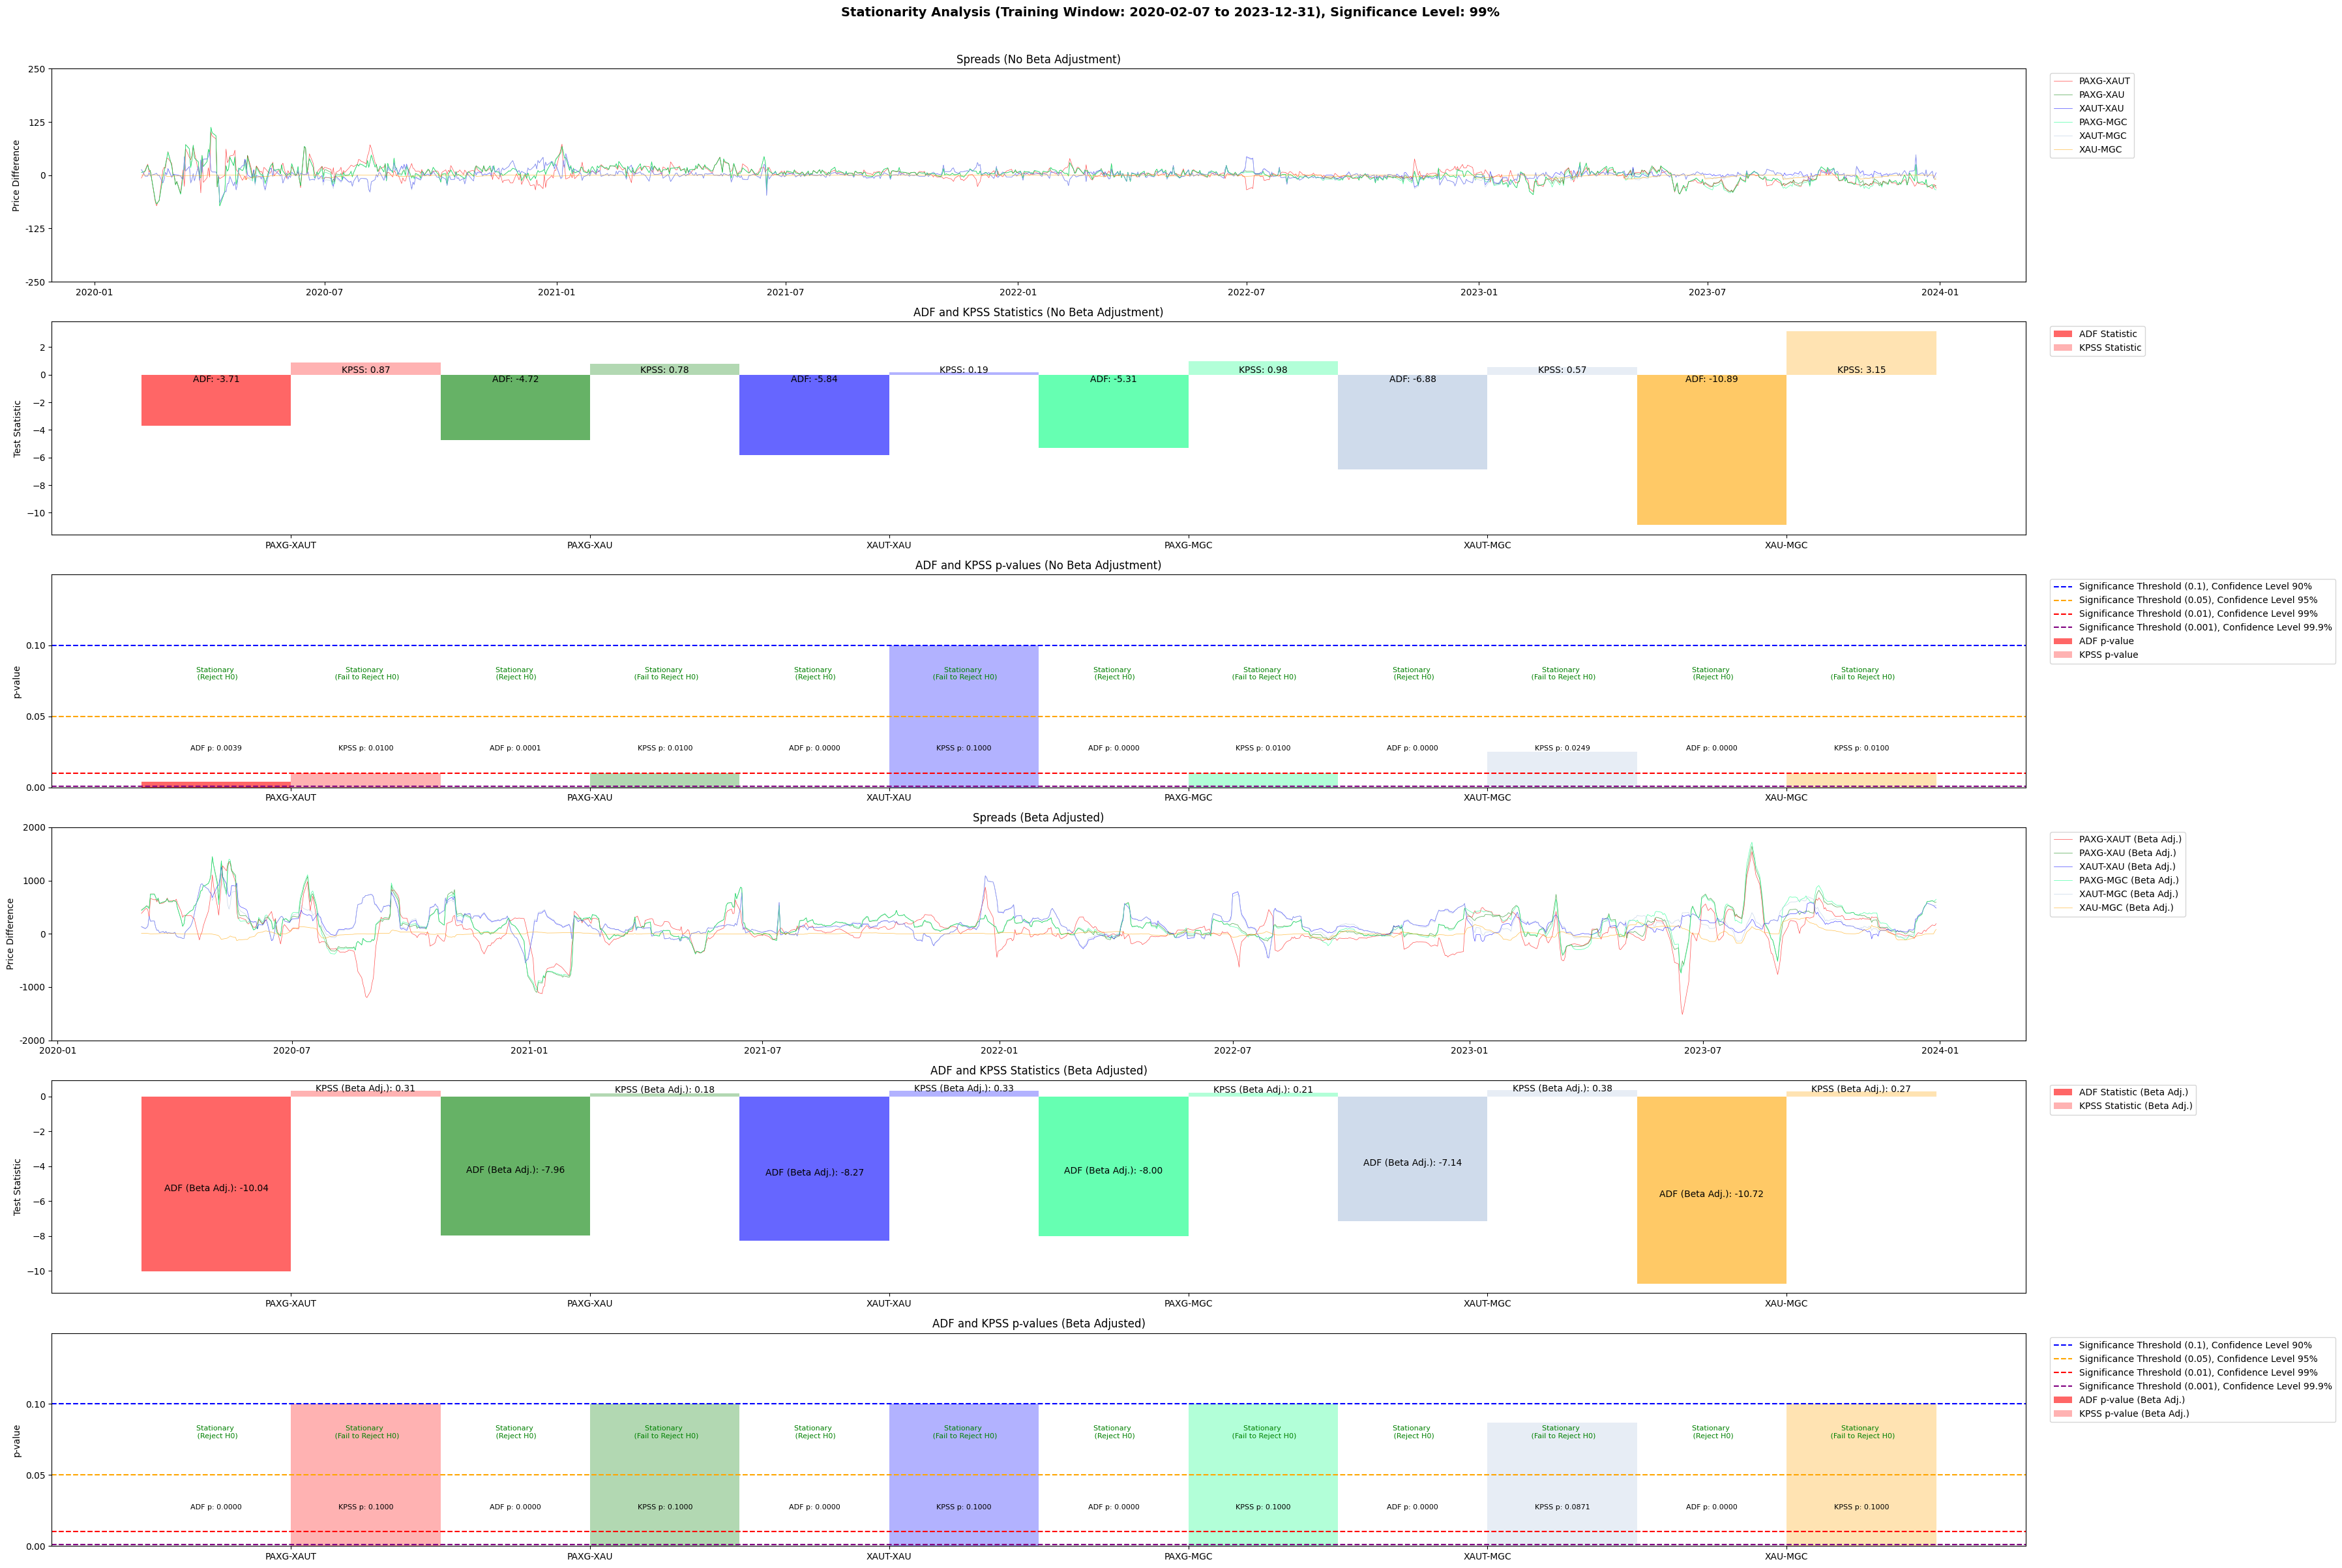

In [18]:
# stationarity plots - p values vs critical values
# *todo change bar chart legend to be neutral blaclk grey 

# Create consistent color scheme for all spreads
colors = ['red', 'green', 'blue', 'springgreen', 'lightsteelblue', 'orange']
spread_names = list(spreads.keys())

fig, axs = plt.subplots(len(spread_names), 1, figsize=(6*len(spread_names), 4*len(spread_names)))#, sharex=True)

# Plot spreads without beta adjustment
for i, (name, series) in enumerate(spreads.items()):
    axs[0].plot(series, color=colors[i], label=name, alpha=0.7, linewidth=0.5)

# Plot ADF and KPSS statistics for regular spreads
bar_width = 0.5
x_positions = np.arange(len(spread_names))

# ADF Statistics (No Beta Adjustment)
adf_values = [adf_stationarity[name]['ADF Statistic'] for name in spread_names]
adf_critical_values = [[adf_stationarity[name]['Critical Values'][cv] for cv in ['1%', '5%', '10%']] for name in spread_names]
axs[1].bar(x_positions - bar_width/2, adf_values, bar_width, 
           color=colors[:len(spread_names)], alpha=0.6, label='ADF Statistic')

for i, (pos, val) in enumerate(zip(x_positions - bar_width/2, adf_values)):
    axs[1].text(pos, 0, f"ADF: {val:.2f}", ha='center', va='bottom' if val >= 0 else 'top')
    added_labels = set()
    # for i, (pos, crit_vals) in enumerate(zip(x_positions - bar_width/2, adf_critical_values)):
    #     for cv_label, cv_value in zip(['1%', '5%', '10%'], crit_vals):
    #         color = 'darkslategray' if cv_label == '1%' else 'darkturquoise' if cv_label == '5%' else 'paleturquoise'
    #         label = f'ADF Critical Value ({cv_label})' if cv_label not in added_labels else None
    #         axs[1].hlines(cv_value, pos - bar_width/2, pos + bar_width/2, colors=color, linestyles='--')# label=label)
    #         added_labels.add(cv_label)

# KPSS Statistics (No Beta Adjustment)
kpss_values = [kpss_stationarity[name]['KPSS Statistic'] for name in spread_names]
kpss_critical_values = [[kpss_stationarity[name]['Critical Values'][cv] for cv in ['10%', '5%', '2.5%', '1%']] for name in spread_names]
axs[1].bar(x_positions + bar_width/2, kpss_values, bar_width, 
           color=colors[:len(spread_names)], alpha=0.3, label='KPSS Statistic')

for i, (pos, val) in enumerate(zip(x_positions + bar_width/2, kpss_values)):
    axs[1].text(pos, 0, f"KPSS: {val:.2f}", ha='center', va='bottom' if val >= 0 else 'top')

    # for i, (pos, crit_vals) in enumerate(zip(x_positions + bar_width/2, kpss_critical_values)):
    #     for cv_label, cv_value in zip(['10%', '5%', '2.5%', '1%'], crit_vals):
    #         color = 'darkslategray' if cv_label == '10%' else 'darkturquoise' if cv_label == '5%' else 'cadetblue' if cv_label == '2.5%' else 'paleturquoise'
    #         label = f'KPSS Critical Value ({cv_label})' if cv_label not in added_labels else None
    #         axs[1].hlines(cv_value, pos - bar_width/2, pos + bar_width/2, colors=color, linestyles='--')#, label=label)
    #         added_labels.add(cv_label)


# p-values for ADF and KPSS tests
axs[2].bar(x_positions - bar_width/2, [adf_stationarity[name]['p-value'] for name in spread_names],
           width=bar_width, color=colors[:len(spread_names)], alpha=0.6, label='ADF p-value')
axs[2].bar(x_positions + bar_width/2, [kpss_stationarity[name]['p-value'] for name in spread_names],
           width=bar_width, color=colors[:len(spread_names)], alpha=0.3, label='KPSS p-value')
for ci, alpha in enumerate(thresholds): 
    axs[2].axhline(list(thresholds.values())[ci], color=threshold_colors[alpha], linestyle='--', label=f'Significance Threshold ({list(thresholds.values())[ci]}), Confidence Level {alpha}')
# ADF p-value annotations (p < threshold (0.05 = Stationary)
for i, (pos, val) in enumerate(zip(x_positions - bar_width/2, [adf_stationarity[name]['p-value'] for name in spread_names])):
    axs[2].text(pos, 0.025, f"ADF p: {val:.4f}", ha='center', va='bottom', fontsize=8)
    axs[2].text(pos, 0.075, f"{'Stationary \n (Reject H0)' if val < thresh else 'Non-Stationary \n (Fail to Reject H0)'}", ha='center', va='bottom', fontsize=8, color='green' if val < thresh else 'red')
# KPSS p-value annotations (p < threshold (0.05 = Non-Stationary) 
for i, (pos, val) in enumerate(zip(x_positions + bar_width/2, [kpss_stationarity[name]['p-value'] for name in spread_names])):
    axs[2].text(pos, 0.025, f"KPSS p: {val:.4f}", ha='center', va='bottom', fontsize=8)
    axs[2].text(pos, 0.075, f"{'Non-Stationary \n (Reject H0)' if val < thresh else 'Stationary \n (Fail to Reject H0)'}", ha='center', va='bottom', fontsize=8, color='red' if val < thresh else 'green')



# Plot spreads with beta adjustment
for i, (name, series) in enumerate(spreads_beta.items()):
    axs[3].plot(series, color=colors[i], label=name + ' (Beta Adj.)', linewidth=0.5, alpha=0.7)

# ADF Statistics (Beta Adjustment)
adf_values_beta = [adf_stationarity_beta[name]['ADF Statistic'] for name in spread_names]
axs[4].bar(x_positions - bar_width/2, adf_values_beta, bar_width, 
           color=colors[:len(spread_names)], alpha=0.6, label='ADF Statistic (Beta Adj.)')
for i, (pos, val) in enumerate(zip(x_positions - bar_width/2, adf_values_beta)):
    axs[4].text(pos, val/2, f"ADF (Beta Adj.): {val:.2f}", ha='center', va='bottom' if val >= 0 else 'top')
# KPSS Statistics (Beta Adjustment)
kpss_values_beta = [kpss_stationarity_beta[name]['KPSS Statistic'] for name in spread_names]
axs[4].bar(x_positions + bar_width/2, kpss_values_beta, bar_width, 
           color=colors[:len(spread_names)], alpha=0.3, label='KPSS Statistic (Beta Adj.)')
for i, (pos, val) in enumerate(zip(x_positions + bar_width/2, kpss_values_beta)):
    axs[4].text(pos, val/2, f"KPSS (Beta Adj.): {val:.2f}", ha='center', va='bottom' if val >= 0 else 'top')


# p-values for ADF and KPSS tests with Beta Adjustment
axs[5].bar(x_positions - bar_width/2, [adf_stationarity_beta[name]['p-value'] for name in spread_names],
           width=bar_width, color=colors[:len(spread_names)], alpha=0.6, label='ADF p-value (Beta Adj.)')
axs[5].bar(x_positions + bar_width/2, [kpss_stationarity_beta[name]['p-value'] for name in spread_names],
              width=bar_width, color=colors[:len(spread_names)], alpha=0.3, label='KPSS p-value (Beta Adj.)')
for ci, alpha in enumerate(thresholds): 
    axs[5].axhline(list(thresholds.values())[ci], color=threshold_colors[alpha], linestyle='--', label=f'Significance Threshold ({list(thresholds.values())[ci]}), Confidence Level {alpha}')
# ADF p-value annotations (p < threshold = Stationary)
for i, (pos, val) in enumerate(zip(x_positions - bar_width/2, [adf_stationarity_beta[name]['p-value'] for name in spread_names])):
    axs[5].text(pos, 0.025, f"ADF p: {val:.4f}", ha='center', va='bottom', fontsize=8)
    axs[5].text(pos, 0.075, f"{'Stationary \n (Reject H0)' if val < thresh else 'Non-Stationary \n (Fail to Reject H0)'}", ha='center', va='bottom', fontsize=8, color='green' if val < thresh else 'red')
# KPSS p-value annotations (p < threshold = Non-Stationary)
for i, (pos, val) in enumerate(zip(x_positions + bar_width/2, [kpss_stationarity_beta[name]['p-value'] for name in spread_names])):
    axs[5].text(pos, 0.025, f"KPSS p: {val:.4f}", ha='center', va='bottom', fontsize=8)
    axs[5].text(pos, 0.075, f"{'Non-Stationary \n (Reject H0)' if val < thresh else 'Stationary \n (Fail to Reject H0)'}", ha='center', va='bottom', fontsize=8, color='red' if val < thresh else 'green')

# Set x-axis labels for bar charts
for ax in [axs[1], axs[2], axs[4], axs[5]]:
    ax.set_xticks(x_positions)
    ax.set_xticklabels(spread_names)

# Set titles and labels
axs[0].set_title('Spreads (No Beta Adjustment)')
axs[0].set_ylabel('Price Difference', position=(0, 0.5))
axs[0].set_ylim(-250, 250)
yticks = np.arange(-250, 300, 125)
axs[0].set_yticks(yticks)
axs[0].set_yticklabels([f"{y:.0f}" for y in yticks])


axs[1].set_title('ADF and KPSS Statistics (No Beta Adjustment)')
axs[1].set_ylabel('Test Statistic')

axs[2].set_title('ADF and KPSS p-values (No Beta Adjustment)')
axs[2].set_ylabel('p-value')

axs[3].set_title('Spreads (Beta Adjusted)')
axs[3].set_ylabel('Price Difference')
axs[3].set_ylim(-2000, 2000)
yticks = np.arange(-2000, 2250, 1000)
axs[3].set_yticks(yticks)
axs[3].set_yticklabels([f"{y:.0f}" for y in yticks])

axs[4].set_title('ADF and KPSS Statistics (Beta Adjusted)')
axs[4].set_ylabel('Test Statistic')

axs[5].set_title('ADF and KPSS p-values (Beta Adjusted)')
axs[5].set_ylabel('p-value')

for i in 2,5:
    axs[i].set_ylim(0, 0.15)
    yticks = np.arange(0, 0.15, 0.05)
    axs[i].set_yticks(yticks)
    axs[i].set_yticklabels([f"{y:.2f}" for y in yticks])

# Add legends
axs[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axs[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axs[2].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axs[3].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axs[4].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axs[5].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle(f'Stationarity Analysis (Training Window: {train_start} to {train_end}), Significance Level: {list(thresholds.keys())[list(thresholds.values()).index(thresh)]}', fontsize=14, fontweight='bold', y=1)
plt.tight_layout(rect=[0, 0, 1, 0.99])  # Leave 1% space at top for suptitle
plt.show()



### 7* results 
all spreads (w and w/o beta adjustments) show stationarity (ADF & KPSS agree) at the 99% confidence interval (α = 0.001)

ADF Stationarity: low p value (p value < threshold), reject H0 (non stationary; series has a unit root)

KPSS Stationarity: high p value (p value > threshold), fail to reject H0 (series is stationary)

next steps will be preliminary test on tokenised pairs (paxg-xaut), then token-futures pairs (xaut-xau, xaut-mgc and so on), this is to allow for testing framework to account for futures trading (lot sizing, min order, maintenance margin, trading hours, broker fees etc.)

will work on all remaning spreads including beta adjusted spreads after the testing framework is fully established.

going forward spread refers to spread between paxg-xaut (preferred first step since its token token and 24/7 trading)

In [19]:
# params redefinition
assetA, assetB = 'PAXG-USD', 'XAUT-USD'
spread = compute_spread(data, assetA, assetB, rolling_window=beta_window, beta=False)[0]
df_1 = data[assetA].copy()
df_2 = data[assetB].copy()

rt_cost = 6 # $/oz 
rt_cost_bps = 80 # bps


### 8. entry/exit threshold optimisation w/ stop loss - zeng & lee (2014)

In [20]:
# optimal entry/exit thresholds via OU return-per-unit-time

# --- 1. Fit OU: dX = mu*(theta - X)dt + sigma dW, via exact AR(1) discretisation (dt = 1 day) ---
def fit_ou(s):
    s = s.dropna(); x0, x1 = s.values[:-1], s.values[1:]
    B, A = np.polyfit(x0, x1, 1)
    mu = -np.log(B); theta = A / (1 - B)
    resid = x1 - (A + B * x0)
    sigma = np.sqrt(resid.var(ddof=2) * 2 * mu / (1 - B**2))
    return mu, theta, sigma

# --- 2. Expected trade length E[T] (dimensionless series, stable recurrence; odd in z) ---
def S(z, nt=200, tol=1e-16):
    term = np.sqrt(2 * np.pi) * z; s = term
    for k in range(1, nt):
        term *= (2*k - 1) * z*z / ((2*k + 1) * (2*k)); s += term
        if abs(term) < tol * abs(s): break
    return s

# --- 3. Optimise a_d for both rules (paper proves exit is 0 or -a_d) ---
def optimise(rule):
    if rule == 'conventional':                        # exit at mean (b_d = 0)
        f = lambda a: -((a - c_d) / ET(a, 0)) if a > c_d else 1e9
    else:                                             # 'new': exit at opposite extreme (b_d = -a_d)
        f = lambda a: -((2*a - c_d) / ET(a, -a)) if 2*a > c_d else 1e9
    return minimize_scalar(f, bounds=(0.05, 6), method='bounded').x# --- 3. Optimise a_d for both rules (paper proves exit is 0 or -a_d) ---
def optimise(rule):
    if rule == 'conventional':                        # exit at mean (b_d = 0)
        f = lambda a: -((a - c_d) / ET(a, 0)) if a > c_d else 1e9
    else:                                             # 'new': exit at opposite extreme (b_d = -a_d)
        f = lambda a: -((2*a - c_d) / ET(a, -a)) if 2*a > c_d else 1e9
    return minimize_scalar(f, bounds=(0.05, 6), method='bounded').x



OU fit: mu=0.2424/day  theta=2.6583  sigma=11.6632
        equilibrium std (z-unit) = 16.7519   half-life = 2.9 days

CONVENTIONAL  entry_z = ±1.11, exit_z = 0        E[T]≈7.1d
NEW (flip)    entry_z = ±0.85, exit_z = ∓0.85  E[T]≈10.0d


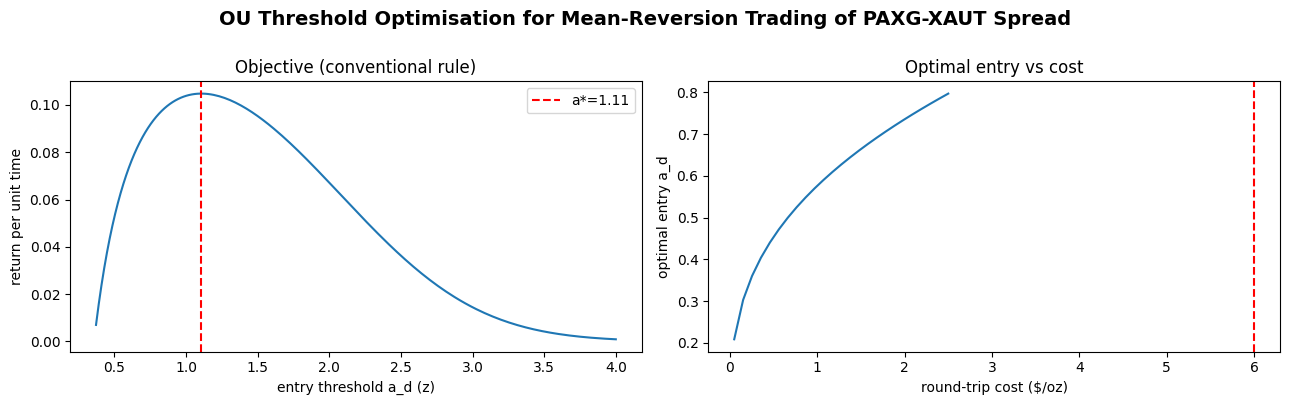

In [21]:
# --- 1. Fit OU: dX = mu*(theta - X)dt + sigma dW, via exact AR(1) discretisation (dt = 1 day) ---

mu, theta, sigma = fit_ou(spread)
sig_eq   = sigma / np.sqrt(2 * mu)      # OU equilibrium std  -> the "z" unit the thresholds live in
half_life = np.log(2) / mu              # trading days
c_d = rt_cost / sig_eq           # cost in dimensionless units



# --- 2. Expected trade length E[T] (dimensionless series, stable recurrence; odd in z) ---

ET = lambda a_d, b_d: (S(a_d) - S(b_d)) / (2 * mu)   # in days

# --- 3. Optimise a_d for both rules (paper proves exit is 0 or -a_d) ---
a_conv = optimise('conventional')
a_new  = optimise('new')

print(f"OU fit: mu={mu:.4f}/day  theta={theta:.4f}  sigma={sigma:.4f}")
print(f"        equilibrium std (z-unit) = {sig_eq:.4f}   half-life = {half_life:.1f} days\n")
print(f"CONVENTIONAL  entry_z = ±{a_conv:.2f}, exit_z = 0        E[T]≈{ET(a_conv,0):.1f}d")
print(f"NEW (flip)    entry_z = ±{a_new:.2f}, exit_z = ∓{a_new:.2f}  E[T]≈{ET(a_new,-a_new):.1f}d")

# --- 4. Standardise the spread in OU units so the thresholds apply exactly ---
df['Z_OU'] = (spread.reindex(df.index) - theta) / sig_eq   # use this as 'Z-Score' with entry_z=a_conv, exit_z=0

# --- 5. Sensitivity: optimal entry vs cost (the one input you don't know precisely) ---
costs = np.linspace(0.05, 2.5, 25)
a_by_cost = []
for cc in costs:
    cd = cc / sig_eq
    a_by_cost.append(minimize_scalar(
        lambda a: -((a - cd)/ET(a,0)) if a > cd else 1e9, bounds=(0.05,6), method='bounded').x)

fig, ax = plt.subplots(1, 2, figsize=(13,4))
grid = np.linspace(0.2, 4, 200)
ax[0].plot(grid, [ -(-((a-c_d)/ET(a,0))) if a>c_d else np.nan for a in grid])
ax[0].axvline(a_conv, color='r', ls='--', label=f'a*={a_conv:.2f}')
ax[0].set_xlabel('entry threshold a_d (z)'); ax[0].set_ylabel('return per unit time'); ax[0].legend()
ax[0].set_title('Objective (conventional rule)')
ax[1].plot(costs, a_by_cost); ax[1].axvline(rt_cost, color='r', ls='--')
ax[1].set_xlabel('round-trip cost ($/oz)'); ax[1].set_ylabel('optimal entry a_d')
ax[1].set_title('Optimal entry vs cost')
plt.suptitle(f'OU Threshold Optimisation for Mean-Reversion Trading of {assetA[:4]}-{assetB[:4]} Spread', fontsize=14, fontweight='bold', y=1)
plt.tight_layout()
plt.show()


C:\Users\y.o\AppData\Local\Temp\ipykernel_21036\2158501501.py:31: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im  = ax1.pcolormesh(a_grid, cost_grid, Z, cmap='coolwarm', shading='auto')
C:\Users\y.o\AppData\Local\Temp\ipykernel_21036\2158501501.py:35: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(); plt.show()


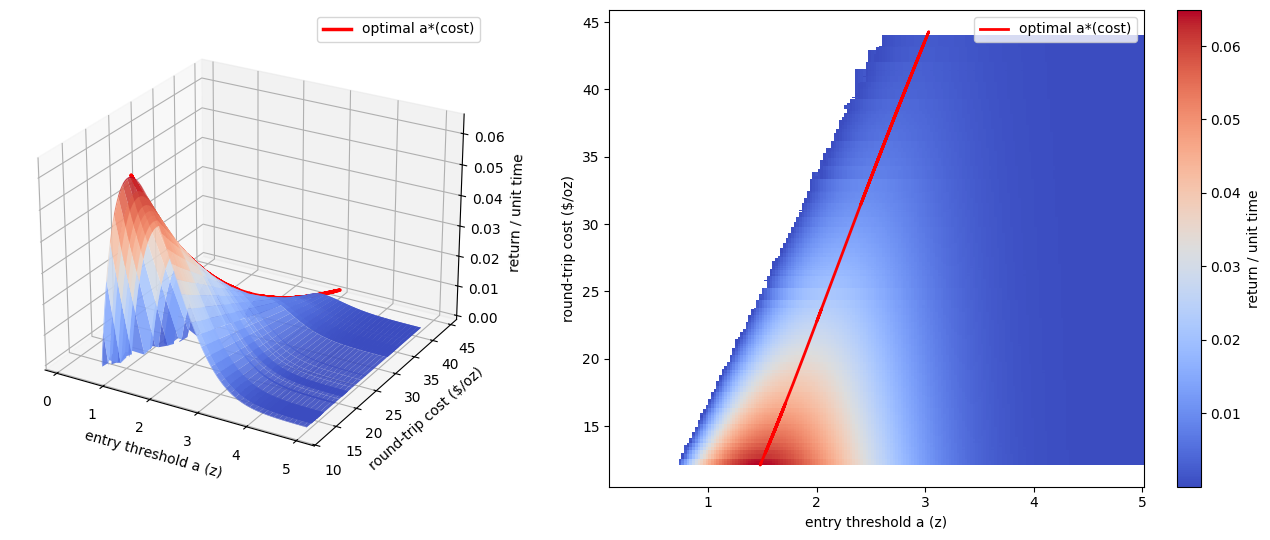

In [22]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

# ---- cost axis: 50bps of price, so $/oz varies with the gold level ----
price_grid = df_1['Close']# * np.linspace(0.8, 1.2, 60)  # realistic range
cost_grid  = rt_cost_bps/1e4 * price_grid             # round-trip cost $/oz
a_grid     = np.linspace(0.1, 5, 200)       # entry threshold (z-units)

# ---- surface: return per unit time (z/day) ----
A, C = np.meshgrid(a_grid, cost_grid)         # (n_cost, n_a)
CD   = C / sig_eq                             # cost -> z-units
ET0  = np.array([ET(a, 0) for a in a_grid])   # ET(a,0) depends only on a
Z    = (A - CD) / ET0[None, :]
Z[A <= CD] = np.nan                           # unprofitable region

# ---- optimal ridge a*(cost) ----
a_star, z_star = [], []
for cost in cost_grid:
    cd = cost / sig_eq
    r  = minimize_scalar(lambda a: -((a-cd)/ET(a,0)) if a>cd else 1e9,
                         bounds=(0.05, 6), method='bounded')
    a_star.append(r.x); z_star.append(-r.fun)

fig = plt.figure(figsize=(14,5.5))
ax0 = fig.add_subplot(1,2,1, projection='3d')
ax0.plot_surface(A, C, Z, cmap='coolwarm', alpha=0.9, linewidth=0)
ax0.plot(a_star, cost_grid, z_star, 'r-', lw=2.5, label='optimal a*(cost)')
ax0.set_xlabel('entry threshold a (z)'); ax0.set_ylabel('round-trip cost ($/oz)')
ax0.set_zlabel('return / unit time'); ax0.view_init(25, -60); ax0.legend()

ax1 = fig.add_subplot(1,2,2)
im  = ax1.pcolormesh(a_grid, cost_grid, Z, cmap='coolwarm', shading='auto')
ax1.plot(a_star, cost_grid, 'r-', lw=2, label='optimal a*(cost)')
ax1.set_xlabel('entry threshold a (z)'); ax1.set_ylabel('round-trip cost ($/oz)')
fig.colorbar(im, ax=ax1, label='return / unit time'); ax1.legend()
plt.tight_layout(); plt.show()

### 9. slippage modelling

#### 9.1 bid ask spread estimation - corwin-schultz (2012) 

In [27]:
# cs estimator function 
def corwin_schultz_spread(
    df: pd.DataFrame,
    high_col: str = "High",
    low_col: str = "Low",
    close_col: Optional[str] = "Close",   # REQUIRED for the overnight adjustment
    overnight_adjust: bool = True,
    agg: str = "rolling",                 # 'rolling' | 'monthly' | 'none'
    window: int = 21,                     # trading days for rolling agg
    min_obs: int = 12,                    # CS require >=12 valid days
    hl_ratio_max: float = 8.0,            # CS reject High/Low > 8
    floor_negative: bool = True,          # MSPREAD_0: floor daily spread at 0 BEFORE averaging
    bps: bool = False,
    pips: bool = False,
    pip_size: float = 0.01,
    absolute: bool = False,
    lag: bool = False,                    # True only if using as a signal known at t-1
) -> pd.Series:
    """
    Corwin & Schultz (2012) high-low spread WITH the original price-cleaning
    and the overnight-return adjustment. Returns spread as a fraction of mid
    (bps/absolute optional). Without close prices the estimator keeps the
    gap-driven downward bias that makes it fall in volatility.
    """
    if bps and absolute:
        raise ValueError("choose one of bps / absolute")
    k = 3.0 - 2.0 * np.sqrt(2.0)

    out = df[[high_col, low_col]].copy()
    out.columns = ["H", "L"]
    out = out.sort_index()                # continuous index; DO NOT dropna before shift(1)

    if close_col is not None and close_col in df.columns:
        out["C"] = df[close_col].reindex(out.index).abs()
    elif overnight_adjust:
        raise ValueError("overnight_adjust=True needs close_col; pass it or "
                         "set overnight_adjust=False (not recommended).")

    H = out["H"].astype(float)
    L = out["L"].astype(float)

    # ---- 1. clean bad bars -> NaN ---------------------------------------
    bad = (H <= 0) | (L <= 0) | (H == L) | (L > H) | (H / L > hl_ratio_max)
    H, L = H.mask(bad), L.mask(bad)

    # ---- 2. overnight-return adjustment (the fix for the vol inversion) --
    # Slide the whole day's range so it connects to the prior close, so the
    # 2-day range (gamma) no longer absorbs the overnight gap.
    if overnight_adjust:
        c_lag = out["C"].shift(1)
        have  = c_lag.notna() & (c_lag > 0) & H.notna() & L.notna()
        gap_up = have & (c_lag < L)        # opened above prior close
        gap_dn = have & (c_lag > H)        # opened below prior close
        H2_, L2_ = H.copy(), L.copy()
        H2_ = H2_.mask(gap_up, H - (L - c_lag)); L2_ = L2_.mask(gap_up, c_lag)
        H2_ = H2_.mask(gap_dn, c_lag);           L2_ = L2_.mask(gap_dn, L + (c_lag - H))
        H, L = H2_, L2_

    # ---- 3. beta, gamma, alpha, spread ----------------------------------
    log_hl = np.log(H / L)
    beta   = log_hl**2 + log_hl.shift(1)**2
    H_2d   = pd.concat([H, H.shift(1)], axis=1).max(axis=1)
    L_2d   = pd.concat([L, L.shift(1)], axis=1).min(axis=1)
    gamma  = np.log(H_2d / L_2d)**2

    alpha  = (np.sqrt(2 * beta) - np.sqrt(beta)) / k - np.sqrt(gamma / k)
    spread = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))     # signed fraction of mid

    daily = spread.clip(lower=0) if floor_negative else spread  # clip preserves NaN

    # ---- 4. units at daily level, then aggregate ------------------------
    mid = (H + L) / 2.0
    if absolute:  daily_out = daily * mid
    elif bps:     daily_out = daily * 1e4
    elif pips:    daily_out = daily * mid / pip_size
    else:         daily_out = daily

    if   agg == "none":    est = daily_out
    elif agg == "rolling": est = daily_out.rolling(window, min_periods=min_obs).mean()
    elif agg == "monthly":
        gp  = daily_out.groupby(daily_out.index.to_period("M"))
        est = gp.mean().where(gp.count() >= min_obs)
    else: raise ValueError("agg must be 'none', 'rolling' or 'monthly'")

    if lag:
        est = est.shift(1)
    return est.dropna()

#### 9.2 naive slippage model

In [24]:
# Naive Slippage Modelling
'''
Total slippage is modelled as a sum of contributions from order volume, asset price volatility, bid-ask spread, and a minimum slippage component which accounts for market maker comp and other costs
ST = Sbase + Svolume + Svolatility + Sspread

Where:
Sbase = P * (m/10000)
Svolume = P * fV * (Q/Vadv)
Svolatility = P * σ * fV
Sspread = S * fS

P = asset price
m = minimum slippage in bps (e.g. 1 bps = 0.01%)
fV = volume impact factor (e.g. 0.1)
Q = order size
Vadv = average daily volume
σ = asset price volatility (e.g. std dev of returns)
fS = spread factor (e.g. 0.5 to reflect that you typically get half the spread as slippage when crossing the spread)
S = bid-ask spread (can be estimated using Abdi Ranaldo model or observed bid-ask spread from data)
'''

class SlippageModel:
    def __init__(
        self,
        volatility_window: int = 20,
        volume_impact_factor: float = 0.1,
        spread_factor: float = 0.5,
        min_slippage_bps: float = 1.0
    ):
        self.volatility_window = volatility_window
        self.volume_impact_factor = volume_impact_factor
        self.spread_factor = spread_factor
        self.min_slippage_bps = min_slippage_bps

    # function to estimate slippage based on the model
    def estimate_slippage(
        self,
        price: float,
        order_size: float,
        avg_daily_volume: float,
        volatility: Optional[float] = None,
        bid_ask_spread: Optional[float] = None
        ) -> float:
            # Base slippage on minimum bps
            base_slippage = price * (self.min_slippage_bps / 10000)

            # Volume impact component
            volume_ratio = order_size / avg_daily_volume
            volume_impact = price * self.volume_impact_factor * volume_ratio

            # Volatility component (if provided)
            volatility_impact = 0
            if volatility is not None:
                volatility_impact = price * volatility * self.volume_impact_factor

            # Spread component
            spread_impact = 0
            if bid_ask_spread is not None and self.spread_factor is not None:
                spread_impact = bid_ask_spread * self.spread_factor
            else:
                # Estimate spread as 0.1% of price if not provided
                spread_impact = price * 0.001 * self.spread_factor

            # Combine all components
            total_slippage = base_slippage + volume_impact + volatility_impact + spread_impact

            return total_slippage

    def calculate_volatility(self, prices: pd.Series) -> float:
        returns = prices.pct_change().dropna()
        volatility = returns.rolling(window=self.volatility_window).std()
        return volatility.iloc[-1]

    def estimate_trade_price(
        self,
        current_price: float,
        order_size: float,
        avg_daily_volume: float,
        is_buy: bool,
        volatility: Optional[float] = None,
        bid_ask_spread: Optional[float] = None
    ) -> float:
        slippage = self.estimate_slippage(
            current_price,
            order_size,
            avg_daily_volume,
            volatility,
            bid_ask_spread
        )

        # Add slippage for buys, subtract for sells
        execution_price = current_price + (slippage if is_buy else -slippage)
        return execution_price

#### 9.3 adv estimation
yahoo finance data omits daily volume traded which is needed to observe order volume's contribution to slippage (participation rate = order size/ average daily volume)
for now use an exponential growth curve with some noise to grow from adv in 2020 to adv today

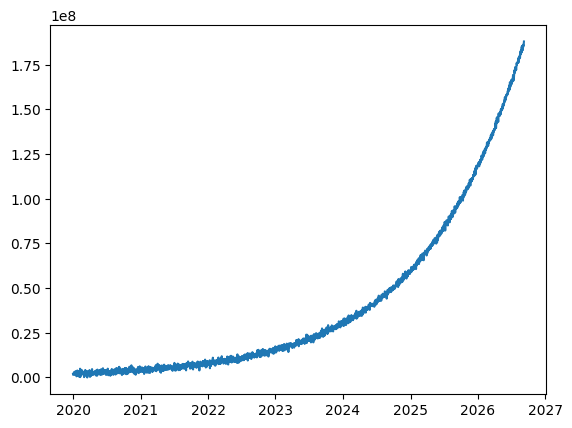

In [31]:
# Approximate average daily volume (ADV) growth from 2020 to 2026
# Use a geometric curve for liquidity growth rather than a linear trend.
adv_20 = 2_000_000     # $2mn
adv_26 = 187_500_000   # $187.5mn

growth_curve = np.geomspace(adv_20, adv_26, num=len(df_1)) + np.random.normal(0, 1_000_000, len(df_1)) 
adv_curve = pd.Series(growth_curve, index=df_1.index, name='ADV')

plt.plot(adv_curve.index, adv_curve.values)

# Example use:
# avg_daily_volume = adv_curve.loc[date]



In [29]:
# nsm test
asset = assetA
ba_spread = corwin_schultz_spread(data[[asset]], high_col='High', low_col='Low', close_col='Close', overnight_adjust=True, agg='rolling', window=20, min_obs=12, hl_ratio_max=8.0, floor_negative=True, bps=True, pips=False, pip_size=0.01, absolute=False, lag=False)


TypeError: cannot use 'list' as a dict key (unhashable type: 'list')

In [26]:
# nsm test
ba_spread = 
model = SlippageModel()
pos = np.random.randint(2)  # Randomly choose buy (1) or sell (0)
date = np.random.choice(data_weekdays[assets[0]].index)  # Random date from data
asset = "XAUT-USD" #np.random.choice(assets)  # Random asset
price = data_weekdays[asset].loc[date, 'Close']
order_size = int(np.round(np.random.uniform(1, 100) / 10) * 10)
order_size = max(order_size, 10)  # prevent 0 when random value is very small
avg_daily_volume = 216_240_000  # avg for paxg in 2025
volatility = model.calculate_volatility(data_weekdays[asset]['Close'].loc[:date])
#bid_ask_spread = spread.loc[pd.Timestamp(date)]
estimated_slippage = model.estimate_slippage(price, order_size, avg_daily_volume)#, volatility, bid_ask_spread)# 0 spread, corwin schultz will cover that...
estimated_price = model.estimate_trade_price(price, order_size, avg_daily_volume, is_buy=bool(pos))#, volatility=volatility, bid_ask_spread=bid_ask_spread)

estimated_slippage_vol = model.estimate_slippage(price, order_size, avg_daily_volume, volatility)#, bid_ask_spread)
estimated_price_vol = model.estimate_trade_price(price, order_size, avg_daily_volume, is_buy=bool(pos), volatility=volatility)#, bid_ask_spread=bid_ask_spread)

print(f"Trade Type: {'Buy' if pos == 1 else 'Sell'}")
print(f"Asset: {asset}")
print(f"Date: {pd.Timestamp(date).strftime('%Y-%m-%d')}")
print(f"Order Size: {order_size} ounces")
print(f"Current Price: ${price:.2f}")
print(f"Execution Price: ${estimated_price:.2f}")
print(f"Notional Value: ${price * order_size:,.2f}")
print(f"Asset Volatility (std dev of returns): {volatility:.4f}")
#print(f"Spread (pips): {(bid_ask_spread):.2f} pips")
#spread_dollars = abs(bid_ask_spread) * 0.01  # 1 pip = $0.01
#print(f"Spread (Price): ${spread_dollars:.4f}")
print("**************** Naive Slippage Estimation ****************")
print(f"Estimated Slippage: ${estimated_slippage:.4f}")
print(f"Estimated Slippage (bps): {estimated_slippage / price * 10000:.2f} bps")
print(f"Estimated Slippage (pips): {estimated_slippage / 0.01:.2f} pips")

print(f"Estimated Broker Fee (Taker): ${price * order_size * 0.0001:.2f} (0.01%)")
print(f"Estimated Total Cost (Price Impact + Broker Fee): ${estimated_price * order_size * 0.0001 + abs(estimated_price - price) * order_size:.2f}")
print(f"Estimated Total Cost ($/oz): ${estimated_price + abs(estimated_price - price):.2f}")

print("**************** Volatility Aware Slippage Estimation ****************")

print(f"Estimated Slippage (Vol Aware): ${estimated_slippage_vol:.4f}")
print(f"Estimated Slippage (bps): {estimated_slippage_vol / price * 10000:.2f} bps")
print(f"Estimated Slippage (pips): {estimated_slippage_vol / 0.01:.2f} pips")

print(f"Estimated Broker Fee (Taker): ${price * order_size * 0.0001:.2f} (0.01%)")
print(f"Estimated Total Cost (Price Impact + Broker Fee): ${estimated_price_vol * order_size * 0.0001 + abs(estimated_price_vol - price) * order_size:.2f}")
print(f"Estimated Total Cost ($/oz): ${estimated_price_vol + abs(estimated_price_vol - price):.2f}")


Trade Type: Buy
Asset: XAUT-USD
Date: 2023-08-30
Order Size: 90 ounces
Current Price: $1942.66
Execution Price: $1943.82
Notional Value: $174,839.33
Asset Volatility (std dev of returns): 0.0038
**************** Naive Slippage Estimation ****************
Estimated Slippage: $1.1657
Estimated Slippage (bps): 6.00 bps
Estimated Slippage (pips): 116.57 pips
Estimated Broker Fee (Taker): $17.48 (0.01%)
Estimated Total Cost (Price Impact + Broker Fee): $122.41
Estimated Total Cost ($/oz): $1944.99
**************** Volatility Aware Slippage Estimation ****************
Estimated Slippage (Vol Aware): $1.8952
Estimated Slippage (bps): 9.76 bps
Estimated Slippage (pips): 189.52 pips
Estimated Broker Fee (Taker): $17.48 (0.01%)
Estimated Total Cost (Price Impact + Broker Fee): $188.07
Estimated Total Cost ($/oz): $1946.45
